In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf

%matplotlib Inline
%config InlineBackend.figure_format="svg"

#### Task №8

Fit simple linear regression using Auto dataset. Target is mpg and predictor is horsepower

In [202]:
url = "auto.csv"
auto = pd.read_csv(url)
auto.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,year,origin,name
0,18.0,8,307.0,130,3504,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165,3693,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150,3436,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150,3433,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140,3449,10.5,70,1,ford torino


In [203]:
model = smf.ols('mpg ~ horsepower', data=auto).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                    mpg   R-squared:                       0.606
Model:                            OLS   Adj. R-squared:                  0.605
Method:                 Least Squares   F-statistic:                     599.7
Date:                Wed, 03 Jun 2026   Prob (F-statistic):           7.03e-81
Time:                        01:11:30   Log-Likelihood:                -1178.7
No. Observations:                 392   AIC:                             2361.
Df Residuals:                     390   BIC:                             2369.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     39.9359      0.717     55.660      0.0

1 - Is there a relationship between the predictor and the response?

Our $H_0$ hypothesis is $\beta_1$ == 0. Then we should take a look at t-statistic and p-value associated with horspower. P-value is less than 0.000 and t-statistic is -24.489. The conclusion - we have enough evidence in order to reject $H_0$, there is a relationship between the horseposer and mpg

2 - How strong is the relationship between the predictor and the response?

In order to find out how strong this relationship we need to take a look at $R^2$ which is the measure of fit. $R^2=0.606$ therefore 60 percent variance explained of mpg. This relationship is not very strong.

3 - Is the relationship between the predictor and the response positive or negative?

Taking into account that coefficient $\beta_1$ is negative we can result that the relationship is negative. With a 100 increase in horesoper, the price decreases by 157

4 - What is the predicted mpg associated with a horsepower of 98? What are the associated 95% confidence and prediction intervals?

In [204]:
predictions = model.get_prediction(auto)
prediction_interval = predictions.summary_frame(alpha=0.05)

In [48]:
auto_predixted_v1 = pd.concat([auto, prediction_interval[["mean", "mean_ci_lower", "mean_ci_upper", "obs_ci_lower", "obs_ci_upper"]]], axis=1)

In [49]:
auto_predixted_v1.loc[auto_predixted_v1["horsepower"] == 98]

,mpg,cylinders,displacement,horsepower,weight,acceleration,year,origin,name,mean,mean_ci_lower,mean_ci_upper,obs_ci_lower,obs_ci_upper
177,22.0,4,121.0,98,2945,14.5,75,2,volvo 244dl,24.467077,23.973079,24.961075,14.809396,34.124758
226,18.5,6,250.0,98,3525,19.0,77,1,ford granada,24.467077,23.973079,24.961075,14.809396,34.124758


Predicted mpg associated with a horsepower of 98 is 24.467077. Confidence interval is $[23.973079, 24.961075]$, prediction interval is $[14.809396, 34.124758]$

**Plot the response and the predictor. Display the least squares regression line.**

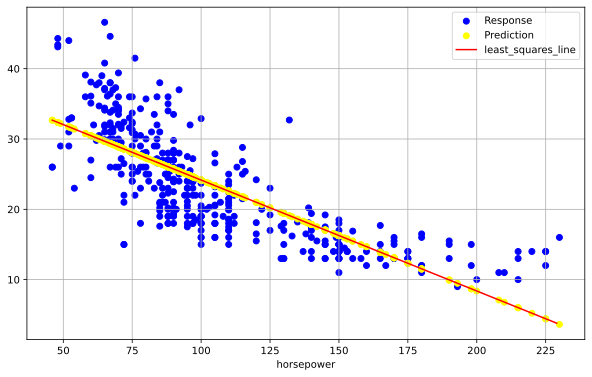

In [89]:
plt.figure(figsize=(10, 6))

intercept = 39.9359
slope = -0.1578
x = np.arange(auto_predixted_v1["horsepower"].min(), auto_predixted_v1["horsepower"].max())
least_squares_line = intercept + x * slope

plt.scatter(auto_predixted_v1["horsepower"], auto_predixted_v1["mpg"], c="blue", label="Response")
plt.scatter(auto_predixted_v1["horsepower"], auto_predixted_v1["mean"], c="yellow", label="Prediction")
plt.plot(x, least_squares_line, c="red", label="least_squares_line")
plt.xlabel("horsepower")

plt.legend(loc="upper right")
plt.grid()

plt.show()

It seems that simple Lenear Regression managed to cought the trend, but the biase of this model is too high. We need to make is more flexible and try multiple linear regression. Although according to the data on the picture there is linear trend in the data.

**Produce diagnostic plots of the least squares regression fit. Comment on any problems you see with the fit.**

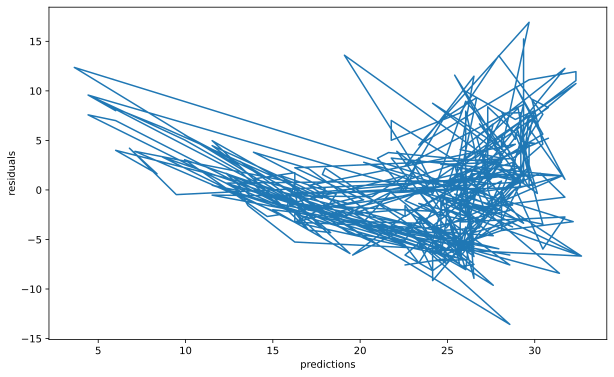

In [90]:
plt.figure(figsize=(10, 6))

plt.plot(auto_predixted_v1["mean"], model.resid)
plt.xlabel("predictions")
plt.ylabel("residuals")

plt.show()

there is a particular shape on the graph - U shape. Hence we have the strong evidence to assume that relationship here is non-linear. Residuals are quite big, and majority is concentrated between -5 and 5.

#### Task №9

This question involves the use of multiple linear regression on the Auto data set.

**Produce a scatterplot matrix which includes all of the variables in the data set**

In [96]:
quantitative_features = auto.drop(columns=["name"])

In [126]:
def plot_qualitative_graphs(df, qulitative_arr, feature):
    fig, axes = plt.subplots(nrows=2, ncols=4, figsize=(15, 15))

    fig.suptitle(f"{feature} as function of quantitative features")
    
    for i in range(8):
        row_ = i // 4
        col_ = i % 4
        ax = axes[row_][col_]

        ax.scatter(df[qulitative_arr[i]], df[feature])
        ax.set_title(f"{feature}/{df.columns[i]}")

    plt.show()

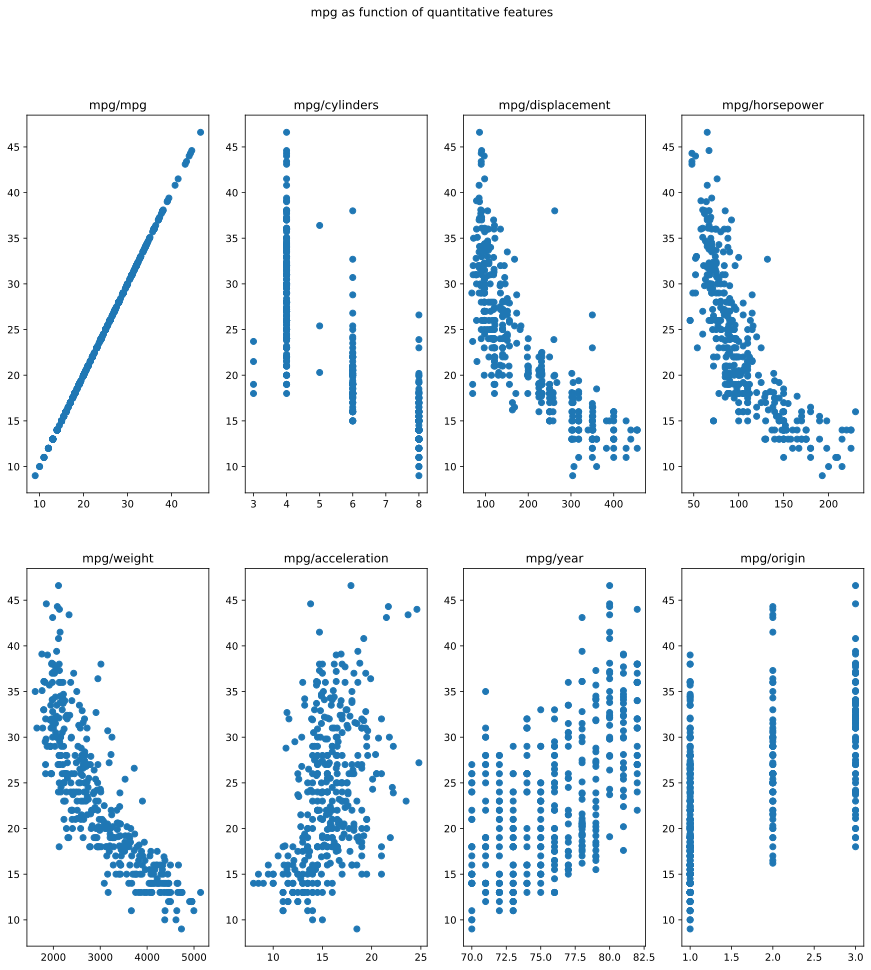

In [127]:
plot_qualitative_graphs(auto, auto.columns[:-1], "mpg")

Regarding the mpg as a function of quantitativ features:
- The more displacemnt the less mpg
- The more horsepower the less mpg
- The more weight the less mpg

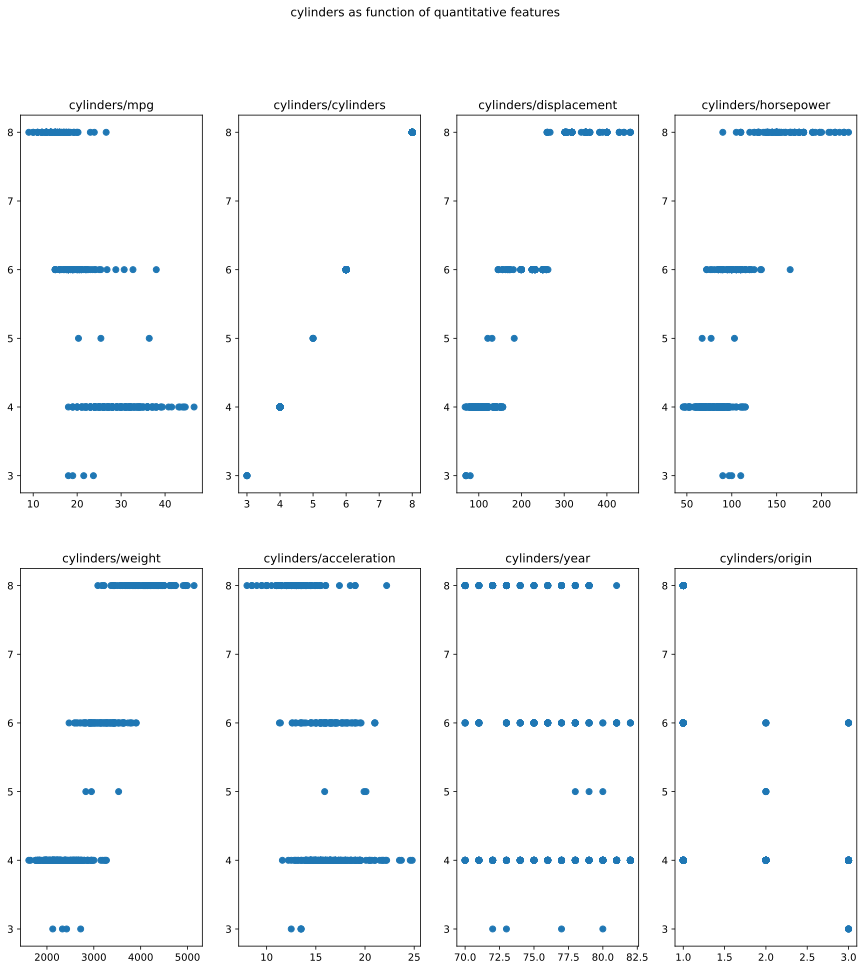

In [128]:
plot_qualitative_graphs(auto, auto.columns[:-1], "cylinders")

It can be seen that the most common values within cylinders feature are 4, 6, 8. Maybe it make sence to make only three group inside this feature

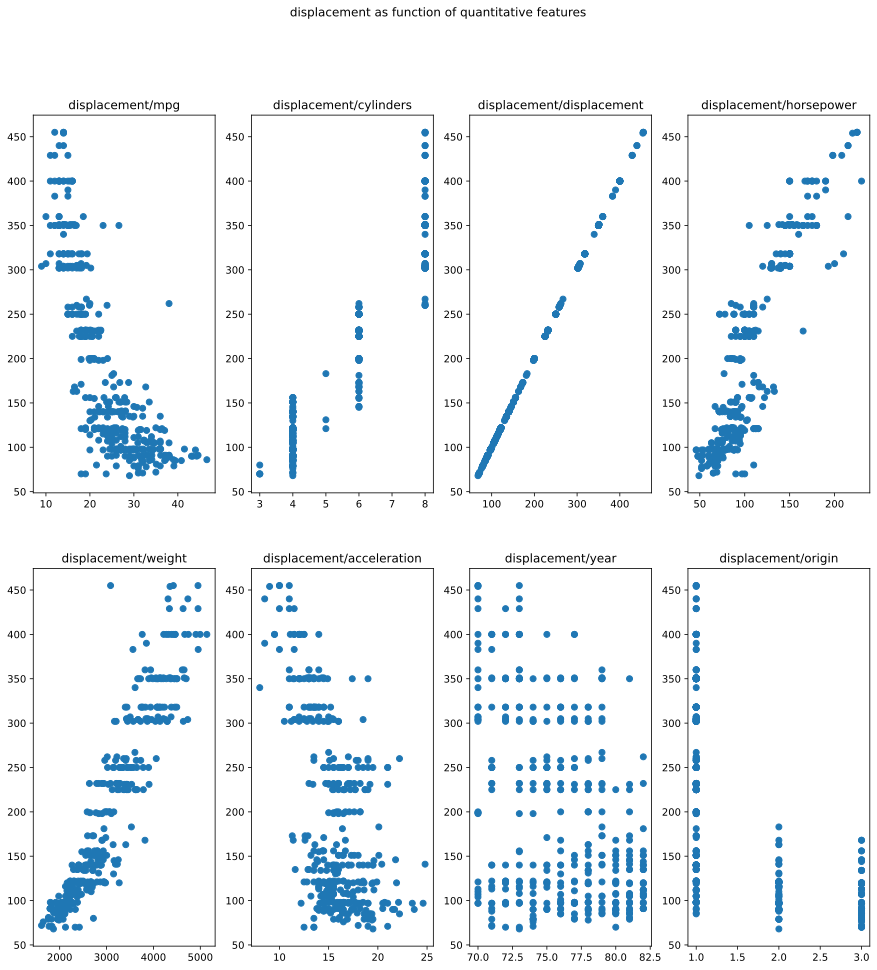

In [129]:
plot_qualitative_graphs(auto, auto.columns[:-1], "displacement")

Regarding the displacement as a function of quantitativ features:
- The more horsepower the more displacement
- The more weight the more displacement

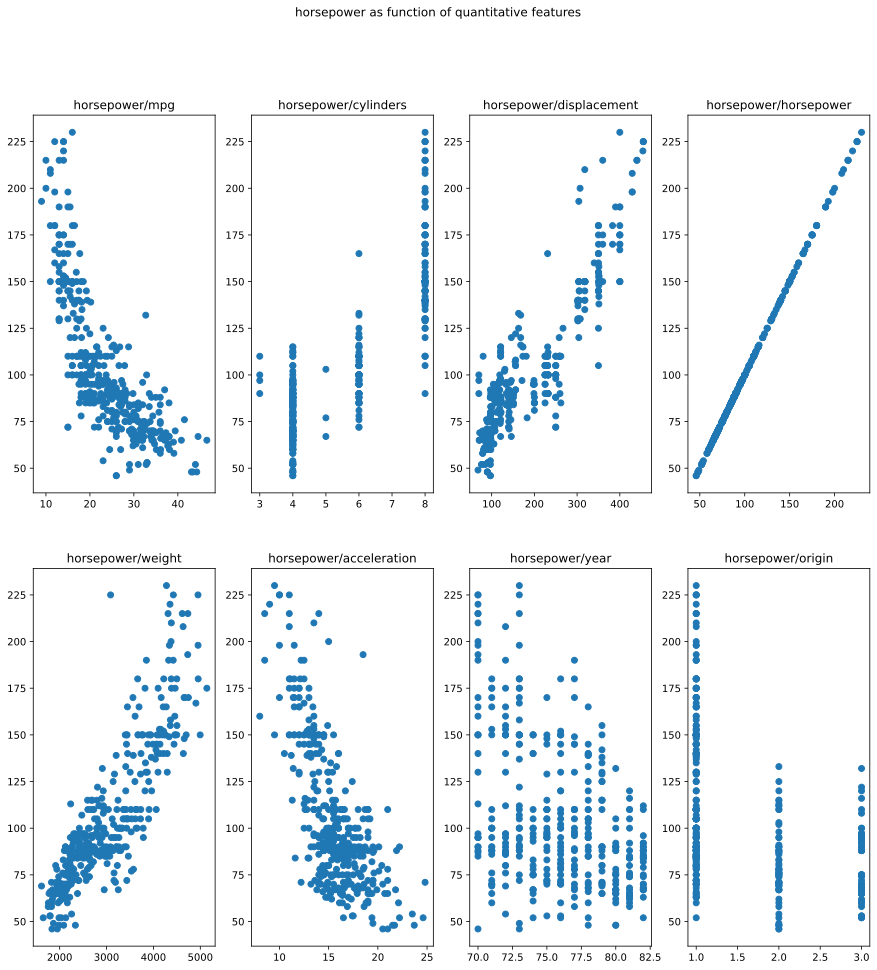

In [130]:
plot_qualitative_graphs(auto, auto.columns[:-1], "horsepower")

Regarding the horsepower as a function of quantitativ features:
- The more acceleration the less horsepower
- The more weight the more horsepower

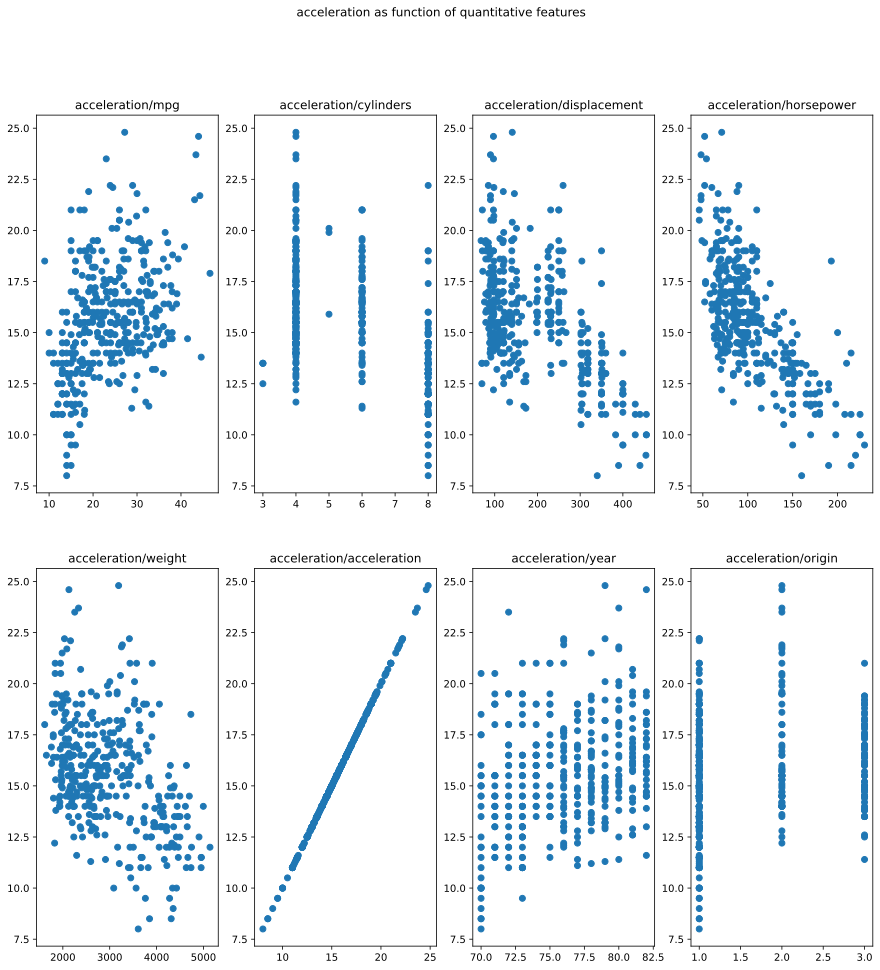

In [133]:
plot_qualitative_graphs(auto, auto.columns[:-1], "acceleration")

Regarding the acceleration as a function of quantitativ features:
- The more horsepower the less acceleration

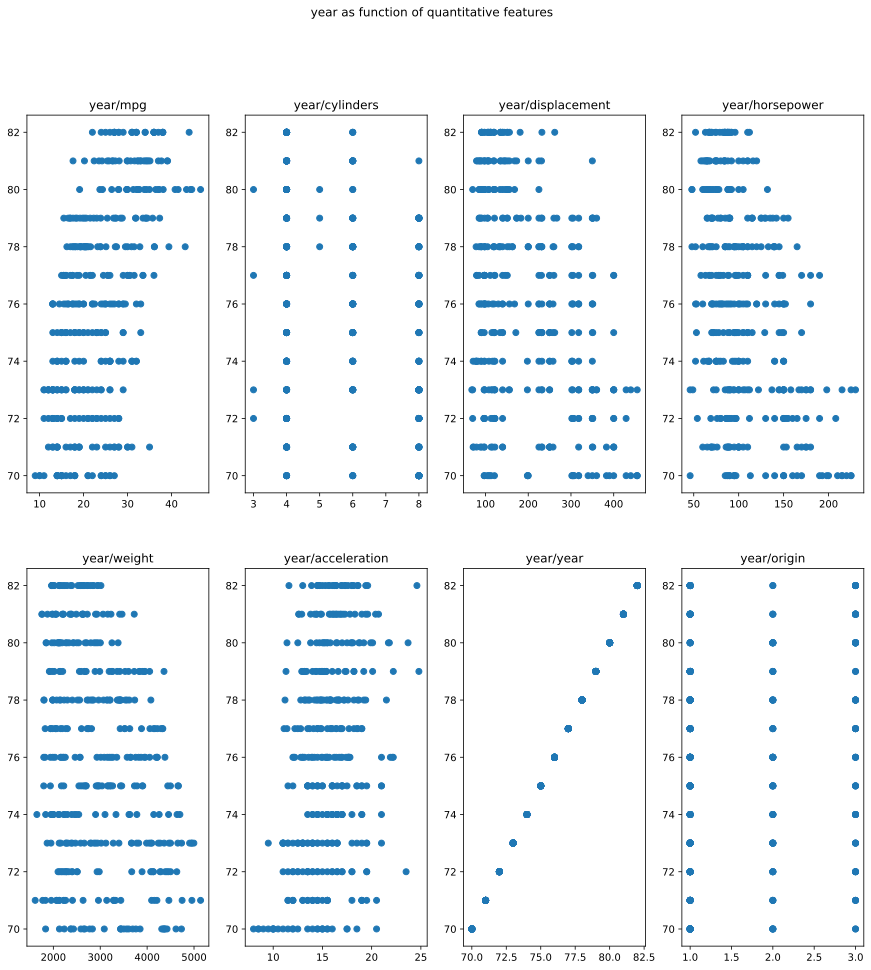

In [135]:
plot_qualitative_graphs(auto, auto.columns[:-1], "year")

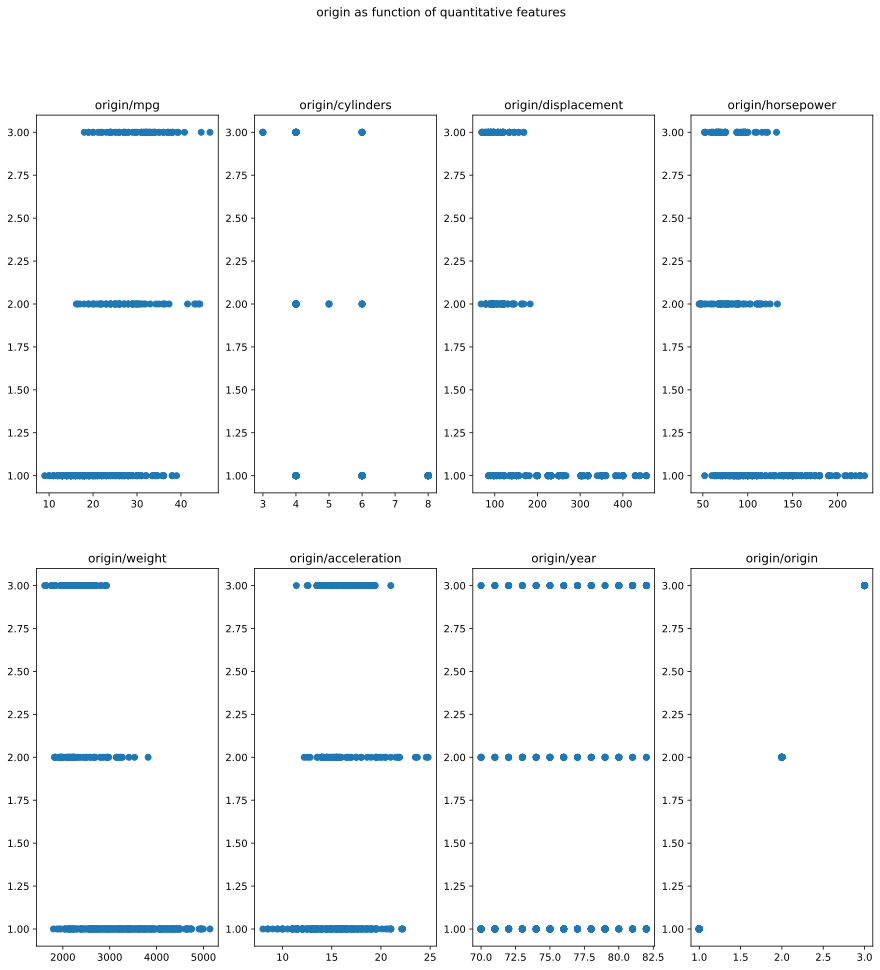

In [136]:
plot_qualitative_graphs(auto, auto.columns[:-1], "origin")

**Compute the matrix of correlations between the variables using the function cor()**

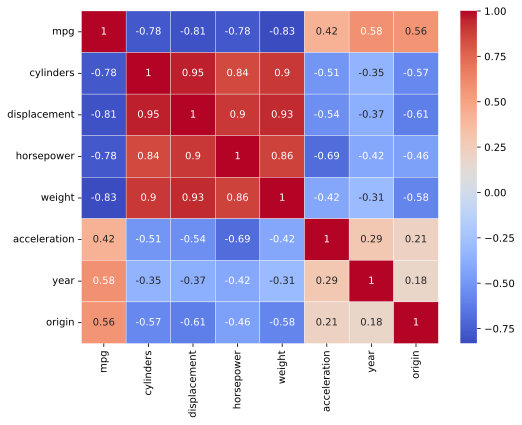

In [140]:
plt.figure(figsize=(8, 6))

matix_corr = np.round(auto.drop(columns=["name"]).corr(), 3)

sns.heatmap(data=matix_corr, linewidths=0.3, annot=True, cmap="coolwarm")

plt.show()

According to the correlation matrix there are a lot of predictors which strongly correlated. Therefore we should deal with multicollinearity in order to prevent problem with effect interpretation. Also any changes in the data can change the value of coefficients and then reduce an accuracy and increase standard error. Calculation t-statistic dependens on coefficient and standard error. Hence non-hypothesis, p-value can be reduced by multicollinearity

**Perform a multiple linear regression with mpg as the response and all other variables except name as the predictors. Print the results.**

In [195]:
equation = auto.columns[0] + " ~ " + " + ".join(auto.columns[1:-1])

model = smf.ols(equation, data=auto).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                    mpg   R-squared:                       0.821
Model:                            OLS   Adj. R-squared:                  0.818
Method:                 Least Squares   F-statistic:                     252.4
Date:                Tue, 02 Jun 2026   Prob (F-statistic):          2.04e-139
Time:                        23:58:38   Log-Likelihood:                -1023.5
No. Observations:                 392   AIC:                             2063.
Df Residuals:                     384   BIC:                             2095.
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept      -17.2184      4.644     -3.707   

1 - Is there a relationship between the predictors and the response?

- In order to find out is there the relationship between the predictors and response we need to take a look at statistics. First of all $t-statistic$ can show us the effect on response by every single predictor separately. Our $H_0$ hypothesis should be $\beta_1=\beta_2=\beta_3=\beta_4=\beta_5=\beta_6=\beta_7=0$ in case our statistic is $f-statistic$ and $\beta_1=0;\beta_2=0;\beta_3=0;\beta_4=0;\beta_5=0;\beta_6=0;\beta_7=0$ in case our statistic is $t-statistic$. F-statistic is equal 252.4 and Prob (F-statistic) is equal 2.04e-139 which means our model is statistically sagnificant. At the same time we can see that p-values for cylinders, horsepower, acceleration are more than 0.05. Hence we can make a conclusion: cylinders, horsepower, acceleration are not statistically sagnificant. The others are statistically sagnificant. But we have to keep in mind that $t-statistic$ show us separate effects our predictors

2 - Which predictors appear to have a statistically significant relationship to the response?

- Take a look one more time at p-values in order to answer this question. The predictors displacement, weight, year and origin are statistically sagnificant because the p-value for them less than 0.05. Also we can track the changes in horsepower variable. It used to be statistically significant, but now this feature lost weight because the multicollinearity. Variables displacement and weight took all payload and horsepower became unusefull.

3 - What does the coefficient for the year variable suggest?

- The year coefficient is positive and means: in case all coefficients are fixed and the year coefficient is equal 0.75, our response mpg will decrease on 0.75.

**Produce diagnostic plots of the linear regression fit. Comment on any problems you see with the fit. Do the residual plots suggest any unusually large outliers? Does the leverage plot identify any observations with unusually high leverage?**

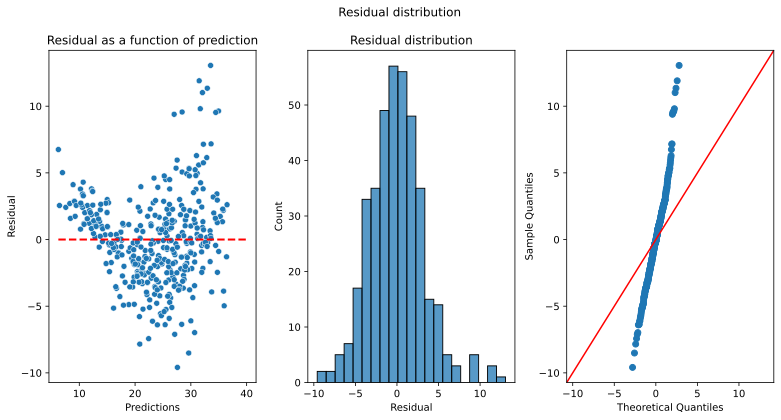

In [196]:
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(13, 6))

fig.suptitle("Residual distribution")

sns.scatterplot(ax=axes[0], x=np.round(model.fittedvalues, 3), y=model.resid)
axes[0].plot(np.linspace(min(model.fittedvalues), 40, 40), [0] * 40, color="red", linestyle="--", linewidth=2)
axes[0].set_xlabel("Predictions")
axes[0].set_ylabel("Residual")
axes[0].set_title("Residual as a function of prediction")

sns.histplot(ax=axes[1], x=model.resid)
axes[1].set_xlabel("Residual")
axes[1].set_ylabel("Count")
axes[1].set_title("Residual distribution")

sm.qqplot(model.resid, line="45", ax=axes[2])

plt.subplots_adjust(wspace=0.25, hspace=0.4)

plt.show()

There is u-shape in chart above. Hence now we have the evidence that the relationship between responce and predictors is non-linear . Residuals are concentrated at 0, majority of them are located in the interval $[-5, 5]$, but there are a few points with residuals more or equal 10. These points can be outliers. Q-Q plot shows heavy tails (both lower and upper) compared to a normal distribution. Normality assumption is violated.

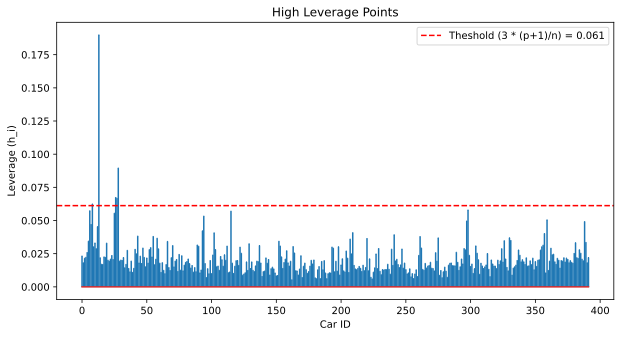

In [183]:
influence = model.get_influence()
leverage = influence.hat_matrix_diag

p = model.df_model
n = model.nobs
leverage_threshold = 3 * (p + 1) / n

plt.figure(figsize=(10, 5))
plt.stem(np.arange(len(leverage)), leverage, markerfmt=",")
plt.axhline(leverage_threshold, color="red", linestyle="--", label=f'Theshold (3 * (p+1)/n) = {leverage_threshold:.3f}')
plt.xlabel("Car ID")
plt.ylabel("Leverage (h_i)")
plt.title("High Leverage Points")
plt.legend()
plt.show()

The graph above displayed the information about high leverage points. We took mean value as $3 * (p + 1) / n$ meaning 3 times more than usual value. Hence there are a few points with high leverage which can influence the model

**Fit linear regression models with interaction effects. Do any interactions appear to be statistically significant?**

In [186]:
features = " + ".join(auto.columns[1:-1])
equation = f"mpg ~ ({features})**2"

model = smf.ols(equation, data=auto).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                    mpg   R-squared:                       0.889
Model:                            OLS   Adj. R-squared:                  0.881
Method:                 Least Squares   F-statistic:                     104.2
Date:                Tue, 02 Jun 2026   Prob (F-statistic):          4.01e-155
Time:                        17:49:25   Log-Likelihood:                -929.72
No. Observations:                 392   AIC:                             1917.
Df Residuals:                     363   BIC:                             2033.
Df Model:                          28                                         
Covariance Type:            nonrobust                                         
                                coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------
Intercept             

In this model we have fitted all possible options of interactions. Within all combinations next were successful - $acceleration:origin$ p-value is 0.004, $$ But Here we should take into account that these coefficints were culculated in the whole model.

**Try a few different transformations of the variables, such as log(X), √X, X2. Comment on your findings.**

In [194]:
equation = auto.columns[0] + " ~ " + " + cylinders + displacement + np.log(horsepower) + np.log(weight) + I(1/acceleration) + year + origin"

model = smf.ols(equation, data=auto).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                    mpg   R-squared:                       0.854
Model:                            OLS   Adj. R-squared:                  0.852
Method:                 Least Squares   F-statistic:                     321.5
Date:                Tue, 02 Jun 2026   Prob (F-statistic):          2.71e-156
Time:                        23:48:35   Log-Likelihood:                -983.71
No. Observations:                 392   AIC:                             1983.
Df Residuals:                     384   BIC:                             2015.
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
Intercept             115.8000    

The model above showed next outcomes:

- THere is a relationship between response and predictores ($f-statistic = 321.5$).
- Almost effetcs are statistically significant exept of cylinders and displacement
- New features are statistically significant and coefficient for them: _log(horsepower)_=7.7734, _log(weight)_=-15.1667 and _reverse acceleration_=64.3649

#### Task №10

This question should be answered using the Carseats data set.

**a)Fit a multiple regression model to predict Sales using Price, Urban, and US**

In [197]:
url = "carseats.csv"
carseats = pd.read_csv(url)
carseats.head()

,Sales,CompPrice,Income,Advertising,Population,Price,ShelveLoc,Age,Education,Urban,US
0,9.50,138,73,11,276,120,Bad,42,17,Yes,Yes
1,11.22,111,48,16,260,83,Good,65,10,Yes,Yes
2,10.06,113,35,10,269,80,Medium,59,12,Yes,Yes
3,7.40,117,100,4,466,97,Medium,55,14,Yes,Yes
4,4.15,141,64,3,340,128,Bad,38,13,Yes,No


In [199]:
model = smf.ols("Sales ~ Price + Urban + US", data=carseats).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                  Sales   R-squared:                       0.239
Model:                            OLS   Adj. R-squared:                  0.234
Method:                 Least Squares   F-statistic:                     41.52
Date:                Wed, 03 Jun 2026   Prob (F-statistic):           2.39e-23
Time:                        00:31:41   Log-Likelihood:                -927.66
No. Observations:                 400   AIC:                             1863.
Df Residuals:                     396   BIC:                             1879.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept       13.0435      0.651     20.036   

**b)Provide an interpretation of each coefficient in the model. Be careful—some of the variables in the model are qualitative!**

- **Urban**: An additional decreasing in sales on 21.9 if it is urban store, comparing with zero effect if it is not urban store
- **US**: An additional increasing in sales on 1200.6 if store is in the US, comparing with zero effect if it is not in the US
- **Price**: The sales value will be reduced on 54.5 in case price increasing on 1

Only one feature $Urban$ is not statistically significant

**c)Write out the model in equation form, being careful to handle the qualitative variables properly.**

$$x_i=\begin{cases} Sales = \beta_0 + \beta_1 * Urban + \beta_2 * US + \beta_3 * Price + e\text{   ->In case all variables are not 0} \\ Sales = \beta_0 + \beta_2 * US + \beta_3 * Price + e\text{   ->In case Urban variable is 0} \\ Sales = \beta_0 + \beta_1 * Urban + \beta_3 * Price + e\text{   ->In case US variable is 0} \end{cases}$$

**d)For which of the predictors can you reject the null hypothesis H0 : βj = 0?**

According to the t-statistic and p-values we can reject null hypothesis for US and Price. The p-value for them less than 0.000

**e)On the basis of your response to the previous question, fit a smaller model that only uses the predictors for which there is evidence of association with the outcome.**

In [200]:
model = smf.ols("Sales ~ Price + US", data=carseats).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                  Sales   R-squared:                       0.239
Model:                            OLS   Adj. R-squared:                  0.235
Method:                 Least Squares   F-statistic:                     62.43
Date:                Wed, 03 Jun 2026   Prob (F-statistic):           2.66e-24
Time:                        01:07:43   Log-Likelihood:                -927.66
No. Observations:                 400   AIC:                             1861.
Df Residuals:                     397   BIC:                             1873.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     13.0308      0.631     20.652      0.0

**f)How well do the models in (a) and (e) fit the data?**

In order to address this question we need take a look at $R^2$ measure. For a model $R^2=0.239$ - it means the model managed to describe 23% of variance sales. For e model $R^2 = 0.239$. Both model reached the same results. The models predict data better than mean model but still quite weak

**g)Using the model from (e), obtain 95 % confidence intervals for the coefficient(s).**

According to the table above, the confidence interval for e model coefficients is:
- Intercept $[11.790, 14.271]$
- US $[0.692, 1.708]$
- Price $[-0.065, -0.044]$

**h)Is there evidence of outliers or high leverage observations in the model from (e)?**

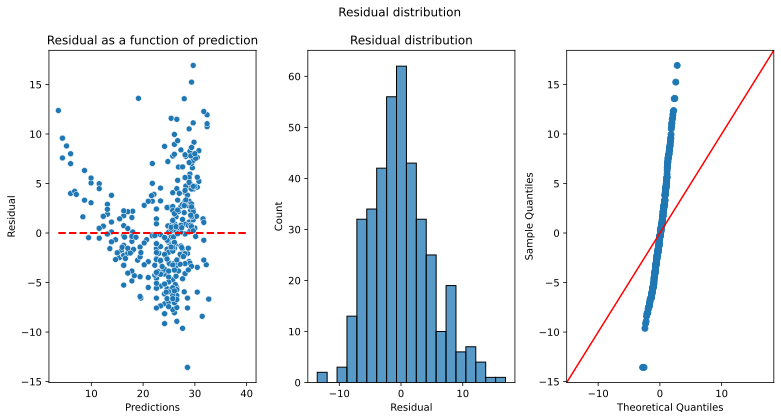

In [205]:
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(13, 6))

fig.suptitle("Residual distribution")

sns.scatterplot(ax=axes[0], x=np.round(model.fittedvalues, 3), y=model.resid)
axes[0].plot(np.linspace(min(model.fittedvalues), 40, 40), [0] * 40, color="red", linestyle="--", linewidth=2)
axes[0].set_xlabel("Predictions")
axes[0].set_ylabel("Residual")
axes[0].set_title("Residual as a function of prediction")

sns.histplot(ax=axes[1], x=model.resid)
axes[1].set_xlabel("Residual")
axes[1].set_ylabel("Count")
axes[1].set_title("Residual distribution")

sm.qqplot(model.resid, line="45", ax=axes[2])

plt.subplots_adjust(wspace=0.25, hspace=0.4)

plt.show()

The left-hand graph displayed the group of points with quite big residuals which are located less than -12 and higher than 12. Q-Q graph showed there are heavy tails on both sides. Also U-shape can be seen on the left-hand graph. Using this information our canclusion is the relationship is non-linear and there are evedince of outliers

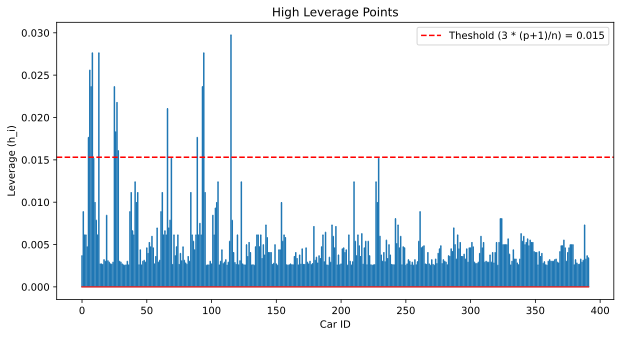

In [206]:
influence = model.get_influence()
leverage = influence.hat_matrix_diag

p = model.df_model
n = model.nobs
leverage_threshold = 3 * (p + 1) / n

plt.figure(figsize=(10, 5))
plt.stem(np.arange(len(leverage)), leverage, markerfmt=",")
plt.axhline(leverage_threshold, color="red", linestyle="--", label=f'Theshold (3 * (p+1)/n) = {leverage_threshold:.3f}')
plt.xlabel("Car ID")
plt.ylabel("Leverage (h_i)")
plt.title("High Leverage Points")
plt.legend()
plt.show()

This model definitely has high leverage points which surpass the mean value

#### Task №11

In this problem we will investigate the t-statistic for the null hypothesis H0 : β = 0 in simple linear regression without an intercept. To
begin, we generate a predictor x and a response y

In [3]:
np.random.seed(42)

x = np.random.normal(100)
y = 2 * x + np.random.normal(size=100)

df = pd.DataFrame({"x": x, "y": y})

**a)Perform a simple linear regression of y onto x, without an intercept. Report the coefficient estimate βˆ, the standard error of
this coefficient estimate, and the t-statistic and p-value associated with the null hypothesis H0 : β = 0. Comment on these
results. (You can perform regression without an intercept using
the command lm(y∼x+0).)**

In [4]:
model = smf.ols("y ~ x + 0", data=df).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.000
Model:                            OLS   Adj. R-squared:                  0.000
Method:                 Least Squares   F-statistic:                       nan
Date:                Wed, 03 Jun 2026   Prob (F-statistic):                nan
Time:                        16:56:24   Log-Likelihood:                -132.56
No. Observations:                 100   AIC:                             267.1
Df Residuals:                      99   BIC:                             269.7
Df Model:                           0                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
x              1.9988      0.001   2194.117      0.0

$\beta_1=1.9988$, $t-statistic=2194.117$, $p-value=0.000$, $SE(\beta_1)=0.001$

- Standard error is quite small which makes t-statistic to become high and p-value very small. Eventually the effect of this variabel is statistically significent. Measure $R^2=0$ that means our model is not better than the mean model

**b) Now perform a simple linear regression of x onto y without an intercept, and report the coefficient estimate, its standard error, and the corresponding t-statistic and p-values associate with the null hypothesis H0 : β = 0. Comment on these results.**

In [5]:
model_b = smf.ols("x ~ y + 0", data=df).fit()
print(model_b.summary())

                                 OLS Regression Results                                
Dep. Variable:                      x   R-squared (uncentered):                   1.000
Model:                            OLS   Adj. R-squared (uncentered):              1.000
Method:                 Least Squares   F-statistic:                          4.814e+06
Date:                Wed, 03 Jun 2026   Prob (F-statistic):                   7.98e-234
Time:                        17:05:07   Log-Likelihood:                         -63.308
No. Observations:                 100   AIC:                                      128.6
Df Residuals:                      99   BIC:                                      131.2
Df Model:                           1                                                  
Covariance Type:            nonrobust                                                  
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------

$\beta_1=0.5003$, $t-statistic=2194.117$, $p-value=0.000$, $SE(\beta_1)=0.000$

- Standard error is equal to 0, t-statistic is high and p-value very small. Eventually the effect of this variabel is statistically significent. This fact was proved by $R^2=1.00$

**c) What is the relationship between the results obtained in (a) and (b)?**

The p-values and t-statistics in both models are equal. Therefore the relationships between them are linear and strong

**f) Show that when regression is performed with an intercept, the t-statistic for H0 : β1 = 0 is the same for the regression of y onto x as it is for the regression of x onto y.**

In [8]:
model_a = smf.ols("y ~ x", data=df).fit()
print(model_b.summary())

                            OLS Regression Results                            
Dep. Variable:                      x   R-squared:                   -1188.967
Model:                            OLS   Adj. R-squared:              -1201.110
Method:                 Least Squares   F-statistic:                    -97.92
Date:                Wed, 03 Jun 2026   Prob (F-statistic):               1.00
Time:                        19:28:52   Log-Likelihood:                 2623.2
No. Observations:                 100   AIC:                            -5242.
Df Residuals:                      98   BIC:                            -5237.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    100.4967   2.18e-11    4.6e+12      0.0

In [7]:
model_b = smf.ols("x ~ y", data=df).fit()
print(model_b.summary())

                            OLS Regression Results                            
Dep. Variable:                      x   R-squared:                   -1188.967
Model:                            OLS   Adj. R-squared:              -1201.110
Method:                 Least Squares   F-statistic:                    -97.92
Date:                Wed, 03 Jun 2026   Prob (F-statistic):               1.00
Time:                        19:28:41   Log-Likelihood:                 2623.2
No. Observations:                 100   AIC:                            -5242.
Df Residuals:                      98   BIC:                            -5237.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    100.4967   2.18e-11    4.6e+12      0.0

$t-statistic$ is the same in both model

#### Task №12

This problem involves simple linear regression without an intercept.

**a) Recall that the coefficient estimate βˆ for the linear regression of Y onto X without an intercept is given by (3.38). Under what circumstance is the coefficient estimate for the regression of X onto Y the same as the coefficient estimate for the regression of Y onto X?**

In order to make coefficients are equal we need to make the next equation: $$\frac{\sum(xy)}{\sum(x^2)}=\frac{\sum(xy)}{\sum(y^2)}$$ 
$$\sum(x^2)=\sum(y^2)$$

**(b) Generate an example in with n = 100 observations in which the coefficient estimate for the regression of X onto Y is different from the coefficient estimate for the regression of Y onto X.**

In [29]:
n = 100
np.random.seed(42)

x = np.random.normal(size=n)
y = 3 * x + np.random.normal(size=100)
df = pd.DataFrame({"x": x, "y": y}, columns=["x", "y"])

model_a = smf.ols("y ~ x + 0", data=df).fit()
print(model_b.summary())

                                 OLS Regression Results                                
Dep. Variable:                      x   R-squared (uncentered):                   0.004
Model:                            OLS   Adj. R-squared (uncentered):             -0.006
Method:                 Least Squares   F-statistic:                             0.4193
Date:                Wed, 03 Jun 2026   Prob (F-statistic):                       0.519
Time:                        20:35:39   Log-Likelihood:                         -138.94
No. Observations:                 100   AIC:                                      279.9
Df Residuals:                      99   BIC:                                      282.5
Df Model:                           1                                                  
Covariance Type:            nonrobust                                                  
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------

In [43]:
n = 100
np.random.seed(42)

x = np.random.normal(size=n)
y = 3 * x + np.random.normal(size=100)
df = pd.DataFrame({"x": x, "y": y}, columns=["x", "y"])

model_b = smf.ols("x ~ y + 0", data=df).fit()
print(model_b.summary())

                                 OLS Regression Results                                
Dep. Variable:                      x   R-squared (uncentered):                   0.884
Model:                            OLS   Adj. R-squared (uncentered):              0.883
Method:                 Least Squares   F-statistic:                              755.9
Date:                Wed, 03 Jun 2026   Prob (F-statistic):                    3.83e-48
Time:                        20:35:55   Log-Likelihood:                         -24.622
No. Observations:                 100   AIC:                                      51.24
Df Residuals:                      99   BIC:                                      53.85
Df Model:                           1                                                  
Covariance Type:            nonrobust                                                  
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------

**(c) Generate an example in R with n = 100 observations in which the coefficient estimate for the regression of X onto Y is the same as the coefficient estimate for the regression of Y onto X.**

In [67]:
n = 100
np.random.seed(42)

x = np.random.normal(size=n)
y = x
df = pd.DataFrame({"x": x, "y": y}, columns=["x", "y"])

model_a = smf.ols("y ~ x + 0", data=df).fit()
print(model_b.summary())

                                 OLS Regression Results                                
Dep. Variable:                      x   R-squared (uncentered):                   1.000
Model:                            OLS   Adj. R-squared (uncentered):              1.000
Method:                 Least Squares   F-statistic:                          4.848e+32
Date:                Wed, 03 Jun 2026   Prob (F-statistic):                        0.00
Time:                        20:36:54   Log-Likelihood:                          3400.9
No. Observations:                 100   AIC:                                     -6800.
Df Residuals:                      99   BIC:                                     -6797.
Df Model:                           1                                                  
Covariance Type:            nonrobust                                                  
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------

In [68]:
n = 100
np.random.seed(42)

x = np.random.normal(size=n)
y = x
df = pd.DataFrame({"x": x, "y": y}, columns=["x", "y"])

model_b = smf.ols("x ~ y + 0", data=df).fit()
print(model_b.summary())

                                 OLS Regression Results                                
Dep. Variable:                      x   R-squared (uncentered):                   1.000
Model:                            OLS   Adj. R-squared (uncentered):              1.000
Method:                 Least Squares   F-statistic:                          4.848e+32
Date:                Wed, 03 Jun 2026   Prob (F-statistic):                        0.00
Time:                        20:36:58   Log-Likelihood:                          3400.9
No. Observations:                 100   AIC:                                     -6800.
Df Residuals:                      99   BIC:                                     -6797.
Df Model:                           1                                                  
Covariance Type:            nonrobust                                                  
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------

#### Task №13

In this exercise you will create some simulated data and will fit simple linear regression models to it. Make sure to use random.seed() prior to
starting part (a) to ensure consistent results.

**(a) Using the rnorm() function, create a vector, x, containing 100
observations drawn from a N(0, 1) distribution. This represents
a feature, X.**

**(b) Using the rnorm() function, create a vector, eps, containing 100
observations drawn from a N(0, 0.25) distribution i.e. a normal
distribution with mean zero and variance 0.25.**

**(c) Using x and eps, generate a vector y according to the model
Y = −1+0.5X + e**

What is the length of the vector y? What are the values of β0
and β1 in this linear model?

In [95]:
np.random.seed(42)

x = np.random.standard_normal(size=100)
e = np.random.normal(loc=0.0, scale=0.5, size=100)
y = -1 + 0.5*x + e

df = pd.DataFrame({"x": x, "y": y})

The length of y is 100. $\beta_0=-1$, $\beta_1=0.5$

**(d) Create a scatterplot displaying the relationship between x and
y. Comment on what you observe.**

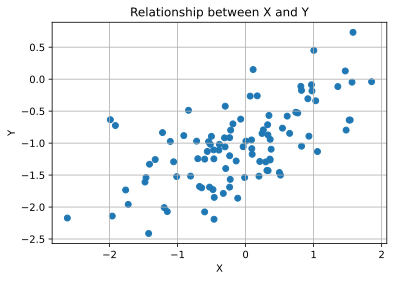

In [76]:
plt.figure(figsize=(6, 4))

plt.scatter(x, y)
plt.xlabel("X")
plt.ylabel("Y")
plt.title("Relationship between X and Y")

plt.grid()

plt.show()

Our point cloud appears to be linear. The more X the more Y with a little bias

**(e) Fit a least squares linear model to predict y using x. Comment
on the model obtained. How do βˆ0 and βˆ1 compare to β0 and
β1?**

In [77]:
model = smf.ols("y ~ x", data=df).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.404
Model:                            OLS   Adj. R-squared:                  0.398
Method:                 Least Squares   F-statistic:                     66.47
Date:                Wed, 03 Jun 2026   Prob (F-statistic):           1.20e-12
Time:                        21:19:52   Log-Likelihood:                -66.393
No. Observations:                 100   AIC:                             136.8
Df Residuals:                      98   BIC:                             142.0
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -0.9963      0.048    -20.847      0.0

The model fitted by OLS has the simmilar values for coefficients:
- $\beta_0=-1$, $\beta_1=0.5$
- $\beta_0=-0.9963$, $\beta_1=0.4284$ fitted model
The effect is statistically significant $p-value=0.000$, the value coefficient is quite stable $SE=0.053$. $R^2=0.404$ 40% of y variance was explained

**(f) Display the least squares line on the scatterplot obtained in (d).
Draw the population regression line on the plot, in a different
color. Use the legend() command to create an appropriate legend.**

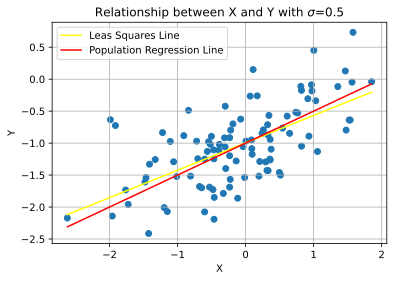

In [102]:
plt.figure(figsize=(6, 4))

least_squares_line = -0.9963 + 0.4284 * x
population_regression_line = -1 + 0.5 * x

plt.scatter(x, y)
plt.plot(x, least_squares_line, c="yellow", label="Leas Squares Line")
plt.plot(x, population_regression_line, c="r", label="Population Regression Line")
plt.xlabel("X")
plt.ylabel("Y")
plt.title("Relationship between X and Y with $\sigma$=0.5")

plt.grid()
plt.legend(loc="upper left")

plt.show()

**(g) Now fit a polynomial regression model that predicts y using x
and x2. Is there evidence that the quadratic term improves the
model fit? Explain your answer.**

In [84]:
model = smf.ols("y ~ x + I(x**2)", data=df).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.432
Model:                            OLS   Adj. R-squared:                  0.420
Method:                 Least Squares   F-statistic:                     36.87
Date:                Wed, 03 Jun 2026   Prob (F-statistic):           1.23e-12
Time:                        22:51:20   Log-Likelihood:                -64.010
No. Observations:                 100   AIC:                             134.0
Df Residuals:                      97   BIC:                             141.8
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -1.0691      0.058    -18.558      0.0

First of all $R^2=0.432$ that is more on 3% than in simple linear model. New variable is statistically significant $p-value=0.032$ it means we have enough evidence to reject $H_0: \beta_1 = 0$. $f-statistic=36.87$, we have only 100 observations therefore there is a connection between variables and target.

**(h) Repeat (a)–(f) after modifying the data generation process in
such a way that there is less noise in the data. The model (3.39)
should remain the same. You can do this by decreasing the variance of the normal distribution used to generate the error term
in (b). Describe your results.**

In [109]:
np.random.seed(42)

x2 = np.random.standard_normal(size=100)
e2 = np.random.normal(loc=0.0, scale=np.sqrt(0.05), size=100)
y2 = -1 + 0.5*x2 + e2

df2 = pd.DataFrame({"x": x2, "y": y2})

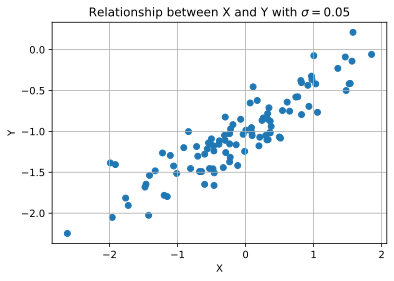

In [110]:
plt.figure(figsize=(6, 4))

plt.scatter(x2, y2)
plt.xlabel("X")
plt.ylabel("Y")
plt.title("Relationship between X and Y with $\sigma=0.05$")

plt.grid()

plt.show()

In [111]:
model2 = smf.ols("y ~ x", data=df2).fit()
print(model2.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.802
Model:                            OLS   Adj. R-squared:                  0.800
Method:                 Least Squares   F-statistic:                     396.6
Date:                Wed, 03 Jun 2026   Prob (F-statistic):           3.18e-36
Time:                        23:34:46   Log-Likelihood:                 14.078
No. Observations:                 100   AIC:                            -24.16
Df Residuals:                      98   BIC:                            -18.95
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -0.9983      0.021    -46.711      0.0

The model fitted by OLS with variance=0.05 has next coefficients:
- $\beta_0=-0.9983$, $\beta_1=0.4680$; $CI=[0.421, 0.515]$ fitted model
The effect is statistically significant $p-value=0.000$, the standard error has become less $SE=0.021$ $\beta_1$ has become more stable. $R^2=0.802$ 80% of y variance was explained, it doubled our last value. The confidence interval has become narrower (because variance)

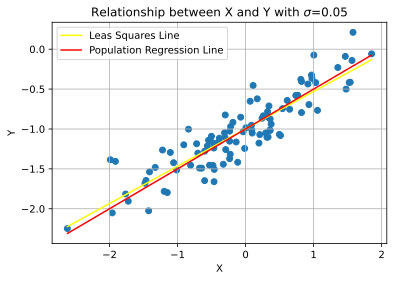

In [125]:
plt.figure(figsize=(6, 4))

least_squares_line = -0.9983 + 0.4680 * x2
population_regression_line = -1 + 0.5 * x2

plt.scatter(x2, y2)
plt.plot(x2, least_squares_line, c="yellow", label="Leas Squares Line")
plt.plot(x2, population_regression_line, c="r", label="Population Regression Line")
plt.xlabel("X")
plt.ylabel("Y")
plt.title("Relationship between X and Y with $\sigma$=0.05")

plt.grid()
plt.legend(loc="upper left")

plt.show()

Cloud points have become narrower coefficients have changed a bit. The Confidence interval has become shorter, $R^2$ doubled

**g) Repeat (a)–(f) after modifying the data generation process in
such a way that there is more noise in the data. The model
(3.39) should remain the same. You can do this by increasing
the variance of the normal distribution used to generate the
error term in (b). Describe your results**

In [127]:
np.random.seed(42)

x3 = np.random.standard_normal(size=100)
e3 = np.random.normal(loc=0.0, scale=np.sqrt(0.8), size=100)
y3 = -1 + 0.5*x3 + e3

df3 = pd.DataFrame({"x": x3, "y": y3})

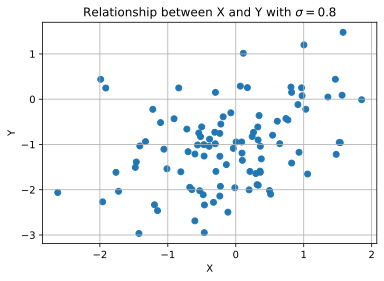

In [128]:
plt.figure(figsize=(6, 4))

plt.scatter(x3, y3)
plt.xlabel("X")
plt.ylabel("Y")
plt.title("Relationship between X and Y with $\sigma=0.8$")

plt.grid()

plt.show()

In [129]:
model3 = smf.ols("y ~ x", data=df3).fit()
print(model3.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.138
Model:                            OLS   Adj. R-squared:                  0.129
Method:                 Least Squares   F-statistic:                     15.65
Date:                Thu, 04 Jun 2026   Prob (F-statistic):           0.000144
Time:                        00:15:49   Log-Likelihood:                -124.55
No. Observations:                 100   AIC:                             253.1
Df Residuals:                      98   BIC:                             258.3
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -0.9934      0.085    -11.620      0.0

The model fitted by OLS with variance=0.8 has next coefficients:
- $\beta_0=-0.9934$, $\beta_1=0.3719$; $CI=[0.185, 0.558]$ fitted model
The effect is statistically significant $p-value=0.000$, the standard error has become more $SE=0.094$ our variable became less stable. $R^2=0.138$ 13% of y variance was explained. $R^2$ reduced dramaticaly

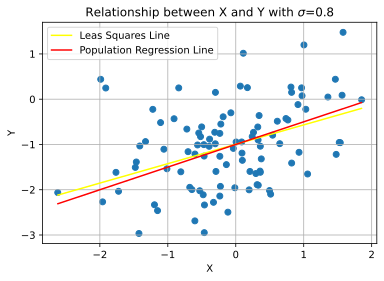

In [130]:
plt.figure(figsize=(6, 4))

least_squares_line = -0.9963 + 0.4284 * x3
population_regression_line = -1 + 0.5 * x3

plt.scatter(x3, y3)
plt.plot(x3, least_squares_line, c="yellow", label="Leas Squares Line")
plt.plot(x3, population_regression_line, c="r", label="Population Regression Line")
plt.xlabel("X")
plt.ylabel("Y")
plt.title("Relationship between X and Y with $\sigma$=0.8")

plt.grid()
plt.legend(loc="upper left")

plt.show()

With increasing variance in the model the measures became worse. $R^2$ showed the minimal value comparing with the others

**(j) What are the confidence intervals for β0 and β1 based on the
original data set, the noisier data set, and the less noisy data
set? Comment on your results.**

When the noise is small the point cloud is located near the line. If noise increases a bit the point cloud will change and is located not so close to the line. If the noise increases dramaticaly our point are quite far from the line. Therefore the confidence interval is getting wider as the noise increases

#### Task №14

This problem focuses on the collinearity problem.

**Perform the following commands in R (Change to Python):**
- set.seed(1) 
- x1=runif (100)
- x2=0.5*x1+rnorm (100)/10
- y=2+2*x1+0.3*x2+rnorm (100)

The last line corresponds to creating a linear model in which y is
a function of x1 and x2. Write out the form of the linear model.
What are the regression coefficients?

In [142]:
np.random.seed(42)

x1 = np.random.uniform(size=100)
x2 = 0.5 * x1 + np.random.uniform(size=100) / 10
y = 2 + 2 * x1 + 0.3 * x2 + np.random.uniform(size=100)
df = pd.DataFrame({"x1": x1, "x2": x2, "y": y})

$y=2 + 2X_1 + 0.3X_2 + e$

Coefficients are $\beta_0 = 2$, $\beta_1 = 2$, $\beta_2 = 0.3$

**(b) What is the correlation between x1 and x2? Create a scatterplot displaying the relationship between the variables.**

In [146]:
x1_x2_corr = df["x1"].corr(df["x2"])
print(f"The correlation between X1 and X2 is {np.round(x1_x2_corr, 3)}")

The correlation between X1 and X2 is 0.981


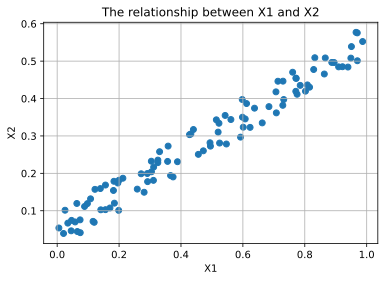

In [147]:
plt.figure(figsize=(6, 4))

plt.scatter(x1, x2)
plt.xlabel("X1")
plt.ylabel("X2")
plt.title("The relationship between X1 and X2")

plt.grid()
plt.show()

It can be clearly seen that the relationship between $X_1$ and $X_2$ is linear. The more $X_1$ the more $X_2$

**(c) Using this data, fit a least squares regression to predict y using
x1 and x2. Describe the results obtained. What are βˆ0, βˆ1, and
βˆ2? How do these relate to the true β0, β1, and β2? Can you
reject the null hypothesis H0 : β1 = 0? How about the null
hypothesis H0 : β2 = 0?**

In [148]:
model = smf.ols("y ~ x1 + x2", data=df).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.825
Model:                            OLS   Adj. R-squared:                  0.821
Method:                 Least Squares   F-statistic:                     228.3
Date:                Thu, 04 Jun 2026   Prob (F-statistic):           2.05e-37
Time:                        18:09:51   Log-Likelihood:                -17.603
No. Observations:                 100   AIC:                             41.21
Df Residuals:                      97   BIC:                             49.02
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      2.6111      0.075     34.618      0.0

This model managed to describe 82% of y variance $R^2=0.825$. There is a relationship between variables and target $f-statistic=228.3$, it is quite high value for this number of observations. The coeffitients for this model next:
- Intercept = 2.6111
- x1 = 2.6977
- x2 = -1.1797

The effects of Intercept and x1 variables are statistically significant, the p-values for them %p-value=0.000%. But the x2 effect is not statistically significant $p-value=0.243$. Therefore we cannot reject $H_0: \beta_2 = 0$ because we do not have enough evidence. But we can reject $H_0: \beta_1=0$. The coefficient are different from the true coeffitients

These effect could be caused by multicollinearity. This model can be confused by X1 and X2 effects bcause they repeat each other, so it is difficult for the model to decide which variabel effect was stronger. At this particular situation the model has decided to choose X1

**(d) Now fit a least squares regression to predict y using only x1.
Comment on your results. Can you reject the null hypothesis
H0 : β1 = 0?**

In [149]:
model_x1 = smf.ols("y ~ x1", data=df).fit()
print(model_x1.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.822
Model:                            OLS   Adj. R-squared:                  0.820
Method:                 Least Squares   F-statistic:                     453.5
Date:                Thu, 04 Jun 2026   Prob (F-statistic):           1.52e-38
Time:                        18:29:53   Log-Likelihood:                -18.308
No. Observations:                 100   AIC:                             40.62
Df Residuals:                      98   BIC:                             45.83
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      2.5505      0.055     46.291      0.0

At this time model managed to describe 82% of y variance $R^2=0.822$. And still there is a relationship between variable and target $f-statistic=453.5$

coefficients:
- Intercept = 2.5505
- x1 = 2.1119

Both are statistically significant $p-vale = 0.000$ we cannot reject $H_0: \beta_1=0$. There is no multicollinearity and model is confident in coefficients

**(e) Now fit a least squares regression to predict y using only x2.
Comment on your results. Can you reject the null hypothesis
H0 : β1 = 0?**

In [150]:
model_x2 = smf.ols("y ~ x2", data=df).fit()
print(model_x2.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.774
Model:                            OLS   Adj. R-squared:                  0.772
Method:                 Least Squares   F-statistic:                     335.7
Date:                Thu, 04 Jun 2026   Prob (F-statistic):           2.03e-33
Time:                        18:36:12   Log-Likelihood:                -30.323
No. Observations:                 100   AIC:                             64.65
Df Residuals:                      98   BIC:                             69.86
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      2.3906      0.071     33.626      0.0

At this time model managed to describe 77% of y variance $R^2=0.774$. And still there is a relationship between variable and target $f-statistic=335.7$

coefficients:
- Intercept = 2.3906
- x1 = 4.0468

Both are statistically significant $p-vale = 0.000$ we cannot reject $H_0: \beta_2=0$. There is no multicollinearity and model is confident in coefficients. Coefficient has changed dramatically

**(f) Do the results obtained in (c)–(e) contradict each other? Explain
your answer.**

Actually they do not contradict each other. When model was fitted using only one of variables the multicollinearity disappeared and this let our model use the effect only one of them and do not separate it between two variables which describe each other. But when we use both variables we have multicollinearity and makes more difficult for the model to decide which feature effected more.

**(g) Now suppose we obtain one additional observation, which was
unfortunately mismeasured.**

- x1=c(x1, 0.1)
- x2=c(x2, 0.8)
- y=c(y,6)

Re-fit the linear models from (c) to (e) using this new data. What
effect does this new observation have on the each of the models?
In each model, is this observation an outlier? A high-leverage
point? Both? Explain your answers.

In [152]:
x1 = np.append(x1, 0.1)
x2 = np.append(x2, 0.8)
y = np.append(y, 6)
df2 = pd.DataFrame({"x1": x1, "x2": x2, "y": y})

In [153]:
model_3 = smf.ols("y ~ x1 + x2", data=df2).fit()
print(model_3.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.799
Model:                            OLS   Adj. R-squared:                  0.795
Method:                 Least Squares   F-statistic:                     194.6
Date:                Thu, 04 Jun 2026   Prob (F-statistic):           7.50e-35
Time:                        18:48:59   Log-Likelihood:                -30.237
No. Observations:                 101   AIC:                             66.47
Df Residuals:                      98   BIC:                             74.32
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      2.3756      0.069     34.362      0.0

At this time the model managed to describe 79.9% of y variance $R^2=0.799$. There is a relationship between variables and target $f-statistic=194.6$

Coefficients are:
- Intercept 2.3756
- x1 0.2225
- x2 3.7532

Currently we cannot reject $H_0: \beta_1=0$ because $p-value=0.346$. Here we only added one point and the result of coefficients hase changed. This proves the fact that we we have multicollinearity our model cannot be shure in the results and any changes in the data can make diffenerce in the result.

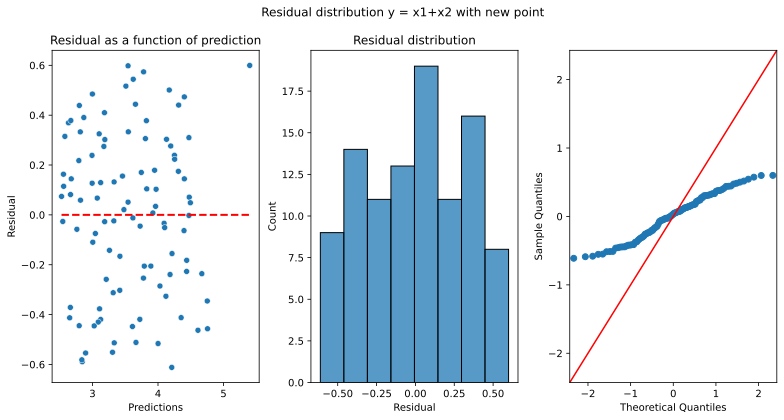

In [180]:
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(13, 6))

fig.suptitle("Residual distribution y = x1+x2 with new point")

sns.scatterplot(ax=axes[0], x=np.round(model_3.fittedvalues, 3), y=model_3.resid)
axes[0].plot(
    np.linspace(min(model_3.fittedvalues), max(model_3.fittedvalues), int(max(model_3.fittedvalues))), 
    [0] * int(max(model_3.fittedvalues)), 
    color="red", 
    linestyle="--", 
    linewidth=2
)
axes[0].set_xlabel("Predictions")
axes[0].set_ylabel("Residual")
axes[0].set_title("Residual as a function of prediction")

sns.histplot(ax=axes[1], x=model_3.resid)
axes[1].set_xlabel("Residual")
axes[1].set_ylabel("Count")
axes[1].set_title("Residual distribution")

sm.qqplot(model_3.resid, line="45", ax=axes[2])

plt.subplots_adjust(wspace=0.25, hspace=0.4)

plt.show()

Here we can see that our new point is different from the rest. The residuals as a function of predictions graph showed point cloud without certain shape. The third and second graphs tell us that the distribution is not normal. The Q-Q graph showes light left tail, the residuals less than expected and the same light right tail, the residuals less than expected. The shape of residuals is appears to be S-form therefore it maight be uniform distribution, but definitely not normal. Regarding outliers: there is no visual evidenc.

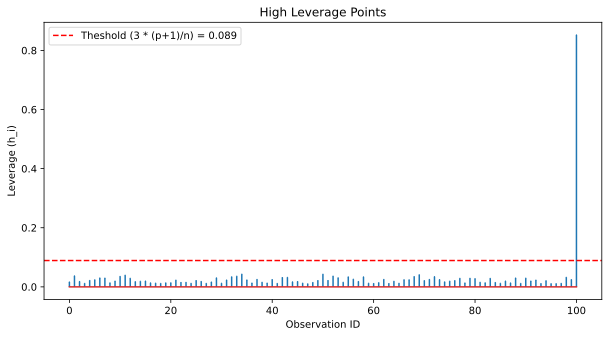

In [194]:
influence = model_3.get_influence()
leverage = influence.hat_matrix_diag

p = model_3.df_model
n = model_3.nobs
leverage_threshold = 3 * (p + 1) / n

plt.figure(figsize=(10, 5))
plt.stem(np.arange(len(leverage)), leverage, markerfmt=",")
plt.axhline(leverage_threshold, color="red", linestyle="--", label=f'Theshold (3 * (p+1)/n) = {leverage_threshold:.3f}')
plt.xlabel("Observation ID")
plt.ylabel("Leverage (h_i)")
plt.title("High Leverage Points")
plt.legend()
plt.show()

According to this graph our new point is a definitely high leverage point

In [181]:
model_4 = smf.ols("y ~ x1", data=df2).fit()
print(model_4.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.651
Model:                            OLS   Adj. R-squared:                  0.647
Method:                 Least Squares   F-statistic:                     184.7
Date:                Thu, 04 Jun 2026   Prob (F-statistic):           2.31e-24
Time:                        19:57:46   Log-Likelihood:                -58.055
No. Observations:                 101   AIC:                             120.1
Df Residuals:                      99   BIC:                             125.3
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      2.6448      0.080     32.855      0.0

Now the model managed to describe 65% of y variance $R^2=0.651$. There is a relationship between variables and target $f-statistic=184.7$

Coefficients are:
- Intercept 2.6448
- x1 1.9785

Currently we can reject $H_0: \beta_1=0$ because $p-value=0.000$. The result is much more worse comparing with the model $y=\beta_0 + x1$. New point caused changes and now the model accuracy decreased

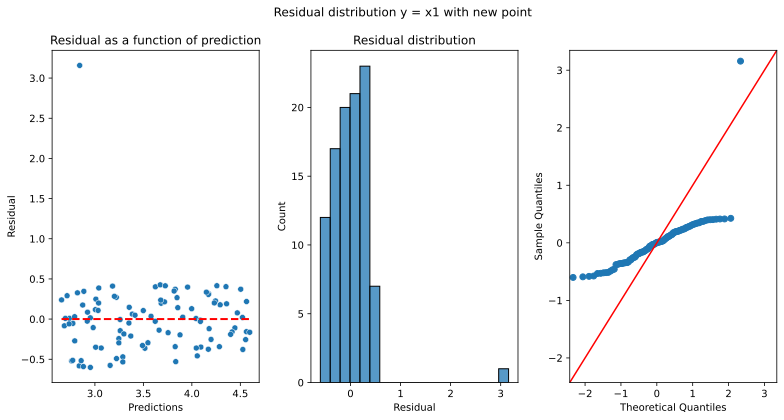

In [186]:
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(13, 6))

fig.suptitle("Residual distribution y = x1 with new point")

sns.scatterplot(ax=axes[0], x=np.round(model_4.fittedvalues, 3), y=model_4.resid)
axes[0].plot(
    np.linspace(min(model_4.fittedvalues), max(model_4.fittedvalues), int(max(model_4.fittedvalues))), 
    [0] * int(max(model_4.fittedvalues)), 
    color="red", 
    linestyle="--", 
    linewidth=2
)
axes[0].set_xlabel("Predictions")
axes[0].set_ylabel("Residual")
axes[0].set_title("Residual as a function of prediction")

sns.histplot(ax=axes[1], x=model_4.resid)
axes[1].set_xlabel("Residual")
axes[1].set_ylabel("Count")
axes[1].set_title("Residual distribution")

sm.qqplot(model_4.resid, line="45", ax=axes[2])

plt.subplots_adjust(wspace=0.25, hspace=0.4)

plt.show()

Here we can see outlier at the first graph and on the third. The Q-Q graph also tells us that the distribution is not normal. Tails are light at the both sides. The distribution is appears to be unifors but not normal

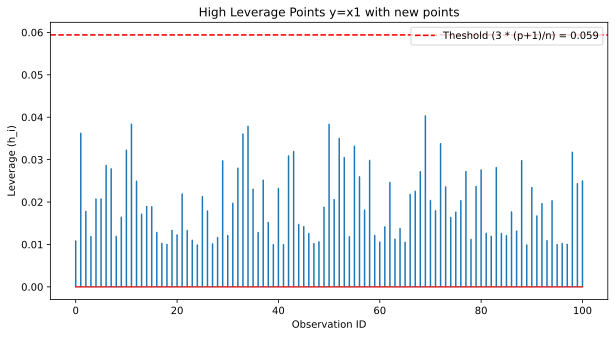

In [193]:
influence = model_4.get_influence()
leverage = influence.hat_matrix_diag

p = model_4.df_model
n = model_4.nobs
leverage_threshold = 3 * (p + 1) / n

plt.figure(figsize=(10, 5))
plt.stem(np.arange(len(leverage)), leverage, markerfmt=",")
plt.axhline(leverage_threshold, color="red", linestyle="--", label=f'Theshold (3 * (p+1)/n) = {leverage_threshold:.3f}')
plt.xlabel("Observation ID")
plt.ylabel("Leverage (h_i)")
plt.title("High Leverage Points y=x1 with new points")
plt.legend()
plt.show()

The graph above tells up that all points are not high levarage.

In [189]:
model_5 = smf.ols("y ~ x2", data=df2).fit()
print(model_5.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.797
Model:                            OLS   Adj. R-squared:                  0.795
Method:                 Least Squares   F-statistic:                     388.6
Date:                Thu, 04 Jun 2026   Prob (F-statistic):           4.72e-36
Time:                        20:04:19   Log-Likelihood:                -30.697
No. Observations:                 101   AIC:                             65.39
Df Residuals:                      99   BIC:                             70.62
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      2.3724      0.069     34.375      0.0

Now the model managed to describe 79.7% of y variance $R^2=0.797$. There is a relationship between variables and target $f-statistic=388.6$

Coefficients are:
- Intercept 2.3724
- x1 4.1224

Currently we can reject $H_0: \beta_2=0$ because $p-value=0.000$. The result is a bit better comparing with the model $y=\beta_0 + x2$. New point caused changes and now the model accuracy increased. Also the value of coefficient has changed dramatically

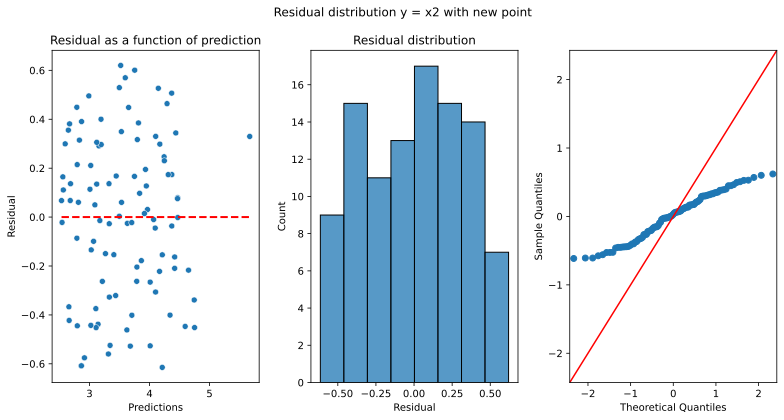

In [190]:
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(13, 6))

fig.suptitle("Residual distribution y = x2 with new point")

sns.scatterplot(ax=axes[0], x=np.round(model_5.fittedvalues, 3), y=model_5.resid)
axes[0].plot(
    np.linspace(min(model_5.fittedvalues), max(model_5.fittedvalues), int(max(model_5.fittedvalues))), 
    [0] * int(max(model_5.fittedvalues)), 
    color="red", 
    linestyle="--", 
    linewidth=2
)
axes[0].set_xlabel("Predictions")
axes[0].set_ylabel("Residual")
axes[0].set_title("Residual as a function of prediction")

sns.histplot(ax=axes[1], x=model_5.resid)
axes[1].set_xlabel("Residual")
axes[1].set_ylabel("Count")
axes[1].set_title("Residual distribution")

sm.qqplot(model_5.resid, line="45", ax=axes[2])

plt.subplots_adjust(wspace=0.25, hspace=0.4)

plt.show()

The conclusion for this model is the same as for y = x1+x2 with new point

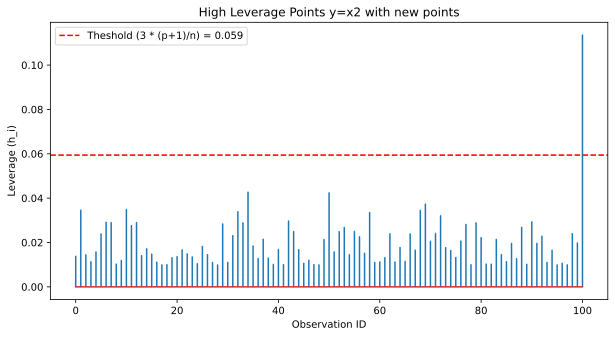

In [192]:
influence = model_5.get_influence()
leverage = influence.hat_matrix_diag

p = model_5.df_model
n = model_5.nobs
leverage_threshold = 3 * (p + 1) / n

plt.figure(figsize=(10, 5))
plt.stem(np.arange(len(leverage)), leverage, markerfmt=",")
plt.axhline(leverage_threshold, color="red", linestyle="--", label=f'Theshold (3 * (p+1)/n) = {leverage_threshold:.3f}')
plt.xlabel("Observation ID")
plt.ylabel("Leverage (h_i)")
plt.title("High Leverage Points y=x2 with new points")
plt.legend()
plt.show()

And again our new point is a high leverage point

#### Task №15

This problem involves the Boston data set, which we saw in the lab
for this chapter. We will now try to predict per capita crime rate
using the other variables in this data set. In other words, per capita
crime rate is the response, and the other variables are the predictors.

**(a) For each predictor, fit a simple linear regression model to predict
the response. Describe your results. In which of the models is
there a statistically significant association between the predictor
and the response? Create some plots to back up your assertions.**

In [196]:
boston = pd.read_csv("Boston.csv")
boston.drop(columns=["Unnamed: 0"], inplace=True, axis=1)

In [218]:
variables = [col for col in boston.columns[1:]]
target = boston.columns[0]

df = pd.DataFrame(columns=["variable", "coefficient", "p-value", "significant"])

for i in range(len(variables)):
    variable = variables[i]
    equation = target + " ~ " + variable
    model = smf.ols(equation, data=boston).fit()
    coefficient = model.params[variable]
    p_value = model.pvalues[variable]
    is_significant = False if p_value > 0.05 else True
    df.loc[df.shape[0] + i] = [variable, coefficient, p_value, is_significant]
df

,variable,coefficient,p-value,significant
0,zn,-0.073935,5.506472e-06,True
2,indus,0.509776,1.450349e-21,True
4,chas,-1.892777,2.094345e-01,False
6,nox,31.248531,3.751739e-23,True
8,rm,-2.684051,6.346703e-07,True
10,age,0.107786,2.854869e-16,True
12,dis,-1.550902,8.519949e-19,True
14,rad,0.617911,2.693844e-56,True
16,tax,0.029742,2.357127e-47,True
18,ptratio,1.151983,2.942922e-11,True


All variables turned out to be statistically significant except of chas. This variable type is bool and itself it cannot find the connection with target. We cannot reject $H_0: \beta_n = 0$ because we do not have enough evidence. Next variables have positive effect: indus, nox, age, rad, tax, ptratio, lstat. Next variables have negative effect: zn, chas, rm, dis, medv.

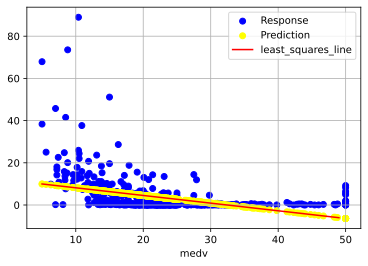

In [249]:
plt.figure(figsize=(6, 4))

m = smf.ols("crim ~ medv", data=boston).fit()

intercept = m.params["Intercept"]
slope = m.params["medv"]
x = np.arange(boston["medv"].min(), boston["medv"].max())
least_squares_line = intercept + x * slope

plt.scatter(boston["medv"], boston["crim"], c="blue", label="Response")
plt.scatter(boston["medv"], m.predict(), c="yellow", label="Prediction")
plt.plot(x, least_squares_line, c="red", label="least_squares_line")
plt.xlabel("medv")

plt.legend(loc="upper right")
plt.grid()

plt.show()

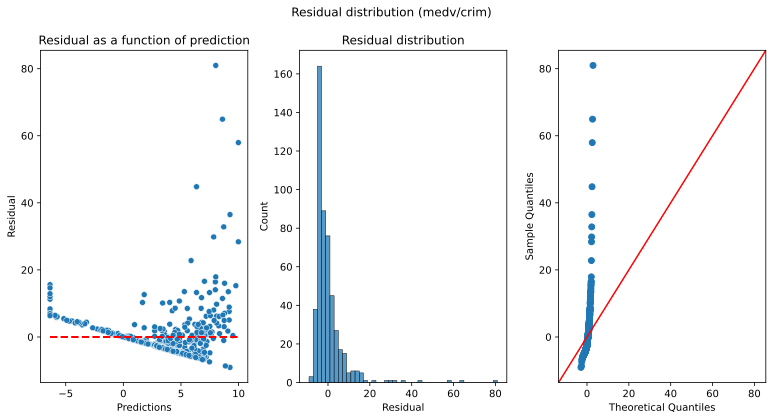

In [243]:
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(13, 6))

fig.suptitle("Residual distribution (medv/crim)")

sns.scatterplot(ax=axes[0], x=np.round(m.fittedvalues, 3), y=m.resid)
axes[0].plot(
    np.linspace(min(m.fittedvalues), max(m.fittedvalues), int(max(m.fittedvalues))), 
    [0] * int(max(m.fittedvalues)), 
    color="red", 
    linestyle="--", 
    linewidth=2
)
axes[0].set_xlabel("Predictions")
axes[0].set_ylabel("Residual")
axes[0].set_title("Residual as a function of prediction")

sns.histplot(ax=axes[1], x=m.resid)
axes[1].set_xlabel("Residual")
axes[1].set_ylabel("Count")
axes[1].set_title("Residual distribution")

sm.qqplot(m.resid, line="45", ax=axes[2])

plt.subplots_adjust(wspace=0.25, hspace=0.4)

plt.show()

There are outliers (graph first and third). Also Q-Q graph showed that our distribution is not normal. Left tail is heavy - model overstates the values for small targets. Right tail is very heavy - model understates the values for big targets. U-shape is a sign of non-linear distribution.

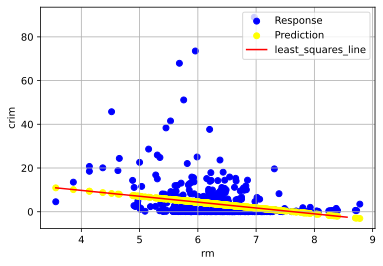

In [246]:
plt.figure(figsize=(6, 4))

m = smf.ols("crim ~ rm", data=boston).fit()

intercept = m.params["Intercept"]
slope = m.params["rm"]
x = np.arange(boston["rm"].min(), boston["rm"].max())
least_squares_line = intercept + x * slope

plt.scatter(boston["rm"], boston["crim"], c="blue", label="Response")
plt.scatter(boston["rm"], m.predict(), c="yellow", label="Prediction")
plt.plot(x, least_squares_line, c="red", label="least_squares_line")
plt.xlabel("rm")
plt.ylabel("crim")

plt.legend(loc="upper right")
plt.grid()

plt.show()

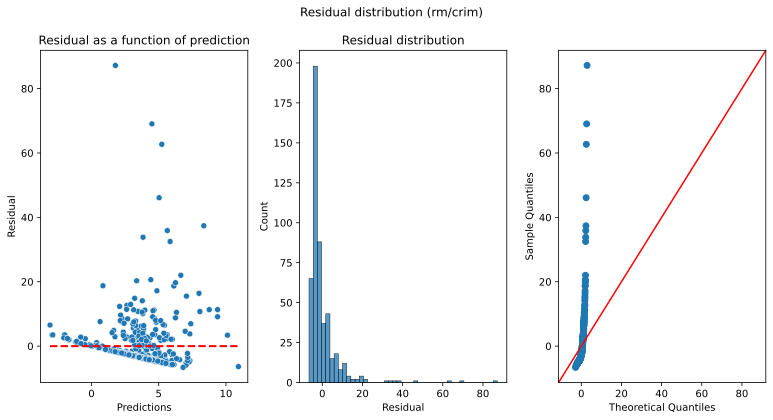

In [248]:
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(13, 6))

fig.suptitle("Residual distribution (rm/crim)")

sns.scatterplot(ax=axes[0], x=np.round(m.fittedvalues, 3), y=m.resid)
axes[0].plot(
    np.linspace(min(m.fittedvalues), max(m.fittedvalues), int(max(m.fittedvalues))), 
    [0] * int(max(m.fittedvalues)), 
    color="red", 
    linestyle="--", 
    linewidth=2
)
axes[0].set_xlabel("Predictions")
axes[0].set_ylabel("Residual")
axes[0].set_title("Residual as a function of prediction")

sns.histplot(ax=axes[1], x=m.resid)
axes[1].set_xlabel("Residual")
axes[1].set_ylabel("Count")
axes[1].set_title("Residual distribution")

sm.qqplot(m.resid, line="45", ax=axes[2])

plt.subplots_adjust(wspace=0.25, hspace=0.4)

plt.show()

This charts look quite similar to previous. There are outliers. The residuals graph have U-shape hence the distribution is non-linear. Also the distribution is not normal becaouse Q-Q chart showed us heavy left tail and very heavy right tail. The model overstates the values for small targets and understates the values for big targets

**(b) Fit a multiple regression model to predict the response using
all of the predictors. Describe your results. For which predictors
can we reject the null hypothesis H0 : βj = 0?**

In [256]:
equation = boston.columns[0] + " ~ " + " + ".join(boston.columns[1:])

model = smf.ols(equation, data=boston).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                   crim   R-squared:                       0.449
Model:                            OLS   Adj. R-squared:                  0.436
Method:                 Least Squares   F-statistic:                     33.52
Date:                Fri, 05 Jun 2026   Prob (F-statistic):           2.03e-56
Time:                        00:07:20   Log-Likelihood:                -1655.4
No. Observations:                 506   AIC:                             3337.
Df Residuals:                     493   BIC:                             3392.
Df Model:                          12                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     13.7784      7.082      1.946      0.0

This model managed to describe 44% of crim variance $R^2=0.449$. The $f-statistic=33.52$, it is not quite big value taking into account that n is equal 506 but stil there is a relationship between variables and target. At this model a lot of features have become statistically insignificant. Next features:
- indus $p-value=0.486$ coefficient -0.0584
- chas $p-value=0.486$ coefficient -0.8254
- nox $p-value=0.060$ coefficient -9.9576
- rm $p-value=0.301$ coefficient 0.6289
- age $p-value=0.962$ coefficient -0.0008
- tax $p-value=0.466$ coefficient -0.0038
- ptratio $p-value=0.103$ coefficient -0.3041
- lstat $p-value=0.067$ coefficient 0.1388

Next are statistically significant
- dis $p-value=0.010$ coefficient -1.0122
- rad $p-value=0.000$ coefficient 0.6125
- zn $p-value=0.015$ coefficient 0.0457
- medv $p-value=0.000$ coefficient -0.2201

For these variables we can reject $H_0: \beta_p = 0$

After union the rm feature has become statistically insignificant. When features work together their weights and p-values can be changed.

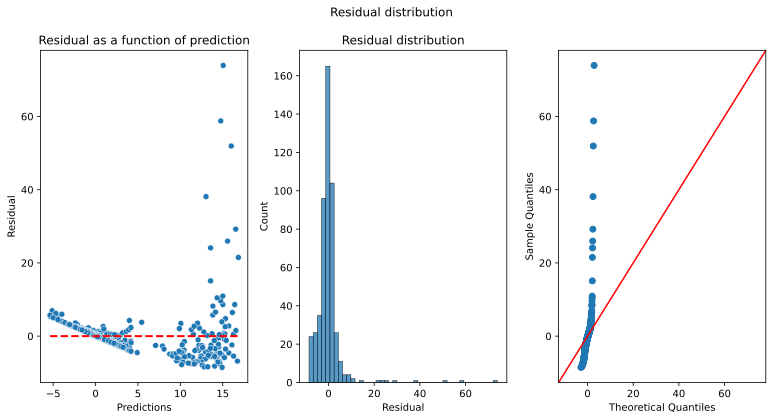

In [257]:
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(13, 6))

fig.suptitle("Residual distribution")

sns.scatterplot(ax=axes[0], x=np.round(model.fittedvalues, 3), y=model.resid)
axes[0].plot(
    np.linspace(min(model.fittedvalues), max(model.fittedvalues), int(max(model.fittedvalues))), 
    [0] * int(max(model.fittedvalues)), 
    color="red", 
    linestyle="--", 
    linewidth=2
)
axes[0].set_xlabel("Predictions")
axes[0].set_ylabel("Residual")
axes[0].set_title("Residual as a function of prediction")

sns.histplot(ax=axes[1], x=model.resid)
axes[1].set_xlabel("Residual")
axes[1].set_ylabel("Count")
axes[1].set_title("Residual distribution")

sm.qqplot(model.resid, line="45", ax=axes[2])

plt.subplots_adjust(wspace=0.25, hspace=0.4)

plt.show()

According to the plots the accuracy of this model is not perfect. First plot results there are outliers. Also first plot displayed light U-shape, therefore the distribution is non-linear. The Q-Q plot repeated the previous result: heavy left tail - the model overstates the values for small targets. Very heavy right tail - the model understates the values for big targets

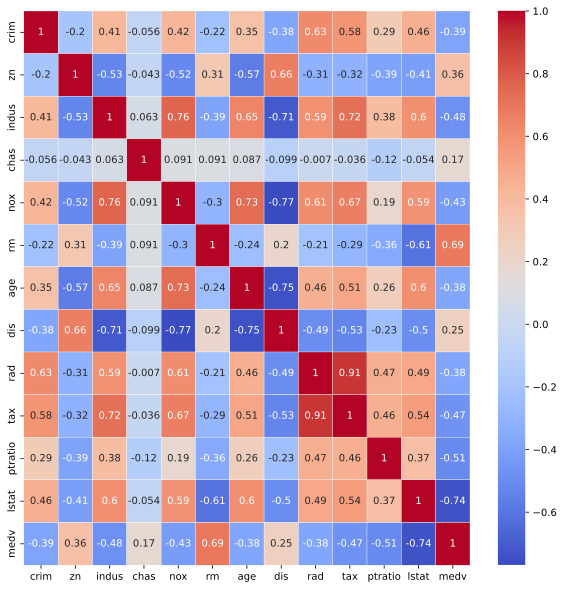

In [259]:
plt.figure(figsize=(10, 10))

corr_matrix = np.round(boston.corr(), 3)

sns.heatmap(data=corr_matrix, annot=True, linewidths=0.3, cmap="coolwarm")

plt.show()

And as we can see there is a multicollinearity. This is the reason why the coefficients are not stable

**(c) How do your results from (a) compare to your results from (b)?
Create a plot displaying the univariate regression coefficients
from (a) on the x-axis, and the multiple regression coefficients
from (b) on the y-axis. That is, each predictor is displayed as a
single point in the plot. Its coefficient in a simple linear regression model is shown on the x-axis, and its coefficient estimate
in the multiple linear regression model is shown on the y-axis.**

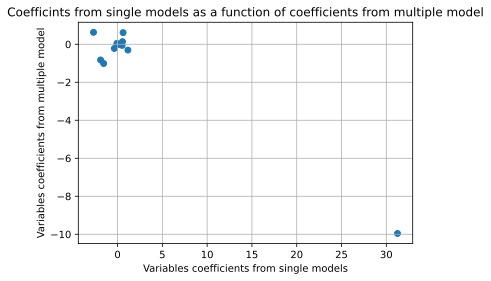

In [267]:
plt.figure(figsize=(6, 4))

plt.scatter(df["coefficient"], model.params[1:])
plt.xlabel("Variables coefficients from single models")
plt.ylabel("Variables coefficients from multiple model")
plt.title("Coefficints from single models as a function of coefficients from multiple model")

plt.grid()

plt.show()

The most distinctive variable coefficient is nox. All variables are concentrated in the left head corner except of nox. It is located in the right bottom corner. This is the reason of unstable values

**(d) Is there evidence of non-linear association between any of the
predictors and the response? To answer this question, for each
predictor X, fit a model of the form
Y = β0 + β1X + β2X2 + β3X3 + e**

In [297]:
variables = [col for col in boston.columns[1:]]
df = pd.DataFrame(columns=[
    "variable", "coefficient", "p-value", "is_significant", 
    "variable**2", "coefficient2", "p-value2", "is_significant", 
    "variable**3", "coefficient3", "p-value3", "is_significant"
])

for i in range(len(variables)):
    current_values = []
    count = 0
    variable = variables[i]
    equation = f"crim ~ {variable} + I({variable}**2) + I({variable}**3)"
    model = smf.ols(equation, data=boston).fit()
    for i in model.params.index[1:]:
        current_values.extend([i, model.params[i], model.pvalues[i], model.pvalues[i] < 0.05])
    df.loc[df.shape[0] + count] = [*current_values]
    count += 1
df

,variable,coefficient,p-value,is_significant,variable**2,coefficient2,p-value2,is_significant,variable**3,coefficient3,p-value3,is_significant
0,zn,-0.332188,2.612296e-03,True,I(zn ** 2),0.006483,9.375050e-02,False,I(zn ** 3),-3.775793e-05,2.295386e-01,False
1,indus,-1.965213,5.297064e-05,True,I(indus ** 2),0.251937,3.420187e-10,True,I(indus ** 3),-6.976009e-03,1.196405e-12,True
2,chas,-0.630926,2.094345e-01,False,I(chas ** 2),-0.630926,2.094345e-01,False,I(chas ** 3),-6.309255e-01,2.094345e-01,False
3,nox,-1279.371252,2.758372e-13,True,I(nox ** 2),2248.544053,6.811300e-15,True,I(nox ** 3),-1.245703e+03,6.961110e-16,True
4,rm,-39.150136,2.117564e-01,False,I(rm ** 2),4.550896,3.641094e-01,False,I(rm ** 3),-1.744770e-01,5.085751e-01,False
5,age,0.273653,1.426608e-01,False,I(age ** 2),-0.007230,4.737733e-02,True,I(age ** 3),5.745307e-05,6.679915e-03,True
6,dis,-15.554353,6.374792e-18,True,I(dis ** 2),2.452072,4.941214e-12,True,I(dis ** 3),-1.185986e-01,1.088832e-08,True
7,rad,0.512736,6.234175e-01,False,I(rad ** 2),-0.075177,6.130099e-01,False,I(rad ** 3),3.208996e-03,4.823138e-01,False
8,tax,-0.153310,1.097075e-01,False,I(tax ** 2),0.000361,1.374682e-01,False,I(tax ** 3),-2.203715e-07,2.438507e-01,False
9,ptratio,-82.360538,3.028663e-03,True,I(ptratio ** 2),4.635347,4.119552e-03,True,I(ptratio ** 3),-8.476032e-02,6.300514e-03,True


According to the calculated DataFrame there is a non-linear relationship between next variables in power 2 and target:
- I(indus ** 2), $p-value=3.420187e-10$
- I(nox ** 2), $p-value=6.811300e-15$
- I(age ** 2), $p-value=4.737733e-02$
- I(dis ** 2), $p-value=4.941214e-12$
- I(ptratio ** 2), $p-value=4.119552e-03$
- I(medv ** 2), $p-value=3.260523e-18$

Also there is a relationship between next features in power 3 and target:
- I(indus ** 2), $p-value=1.196405e-12$
- I(nox ** 3), $p-value=6.961110e-16$
- I(age ** 3), $p-value=6.679915e-03$
- I(dis ** 3), $p-value=1.088832e-08$
- I(ptratio ** 3), $p-value=6.300514e-03$
- I(medv ** 3), $p-value=1.046510e-12$

For them we can reject $H_0$ hypothesis. Therefore it makes sense to make our model a bit more flexible and calculate the result

The coefficients and p-values for chars variable are equals. This feature is binary (bool) and there is no sense trying to transform it in polinom. Variables above showed that adding polinoms inproved the relationship between variables and target 